<a href="https://colab.research.google.com/github/KeshavFTW099/R_Programming/blob/main/IDS_CaseStudy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Introduction To Data Science: CASE STUDY ON GYM USERS DATASET**

**Objective 1: Import and Inspect the Dataset**

In [105]:
# Read
data <- read.csv("/content/gym_data_quality_case_study_100.csv",
                 stringsAsFactors = FALSE)
head(data)
tail(data)

summary(data)

,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,1,Rahul,45,50,60,1900.0
2,2,Arjun,50,55,70,2000.0
3,3,Karan,55,60,75,2100.0
4,4,Vikram,60,65,80,2200.0
5,5,Rohan,65,70,85,2300.0
6,6,Aditya,NA,75,90,2400.0


,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
95,95,Vishnu,65,70,85,7000.0
96,1,Rahul,45,50,60,1900.0
97,2,Arjun,50,55,70,2000.0
98,3,Karan,55,60,75,2100.0
99,4,Vikram,60,65,80,2200.0
100,5,Rohan,65,70,85,2300.0


   Member_ID            Name     Bench_Press_kg   Lat_Pulldown_kg 
 Min.   : 1.00   Length   :100   Min.   :-20.00   Min.   :-15.00  
 1st Qu.:20.75   N.unique : 65   1st Qu.: 55.00   1st Qu.: 60.00  
 Median :45.50   N.blank  :  0   Median : 65.00   Median : 70.00  
 Mean   :45.75   Min.nchar:  3   Mean   : 67.81   Mean   : 74.11  
 3rd Qu.:70.25   Max.nchar:  9   3rd Qu.: 80.00   3rd Qu.: 85.00  
 Max.   :95.00                   Max.   :250.00   Max.   :300.00  
                                 NAs    :4        NAs    :4       
    Squat_kg        Calorie_Intake
 Min.   :-30.00   Length   :100   
 1st Qu.: 73.75   N.unique : 15   
 Median : 85.00   N.blank  :  3   
 Mean   : 89.90   Min.nchar:  0   
 3rd Qu.: 96.25   Max.nchar: 13   
 Max.   :400.00                   
 NAs    :4                        

In [82]:
str(data)

'data.frame':	100 obs. of  6 variables:
 $ Member_ID      : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Name           : chr  "Rahul" "Arjun" "Karan" "Vikram" ...
 $ Bench_Press_kg : num  45 50 55 60 65 NA 75 80 85 90 ...
 $ Lat_Pulldown_kg: num  50 55 60 65 70 75 80 85 90 NA ...
 $ Squat_kg       : num  60 70 75 80 85 90 95 100 110 120 ...
 $ Calorie_Intake : chr  "1900.0" "2000.0" "2100.0" "2200.0" ...


**Objective 2: Identify Missing Values and Incomplete Records**

In [83]:
colSums(is.na(data))

Member_ID            Name  Bench_Press_kg Lat_Pulldown_kg        Squat_kg 
              0               0               4               4               4 
 Calorie_Intake 
              0

In [84]:
sum(is.na(data))

[1] 12

In [85]:
missing_percentage <- colSums(is.na(data)) / nrow(data) * 100

missing_percentage

Member_ID            Name  Bench_Press_kg Lat_Pulldown_kg        Squat_kg 
              0               0               4               4               4 
 Calorie_Intake 
              0

**Objective 3: Detect Duplicate Observations**

In [86]:
sum(duplicated(data))

[1] 5

In [87]:
data[duplicated(data), ]

,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
96,1,Rahul,45,50,60,1900.0
97,2,Arjun,50,55,70,2000.0
98,3,Karan,55,60,75,2100.0
99,4,Vikram,60,65,80,2200.0
100,5,Rohan,65,70,85,2300.0


In [88]:
data[duplicated(data) | duplicated(data, fromLast = TRUE), ]

,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
1,1,Rahul,45,50,60,1900.0
2,2,Arjun,50,55,70,2000.0
3,3,Karan,55,60,75,2100.0
4,4,Vikram,60,65,80,2200.0
5,5,Rohan,65,70,85,2300.0
96,1,Rahul,45,50,60,1900.0
97,2,Arjun,50,55,70,2000.0
98,3,Karan,55,60,75,2100.0
99,4,Vikram,60,65,80,2200.0


**Objective 4: Identify Incorrect or Inconsistent Data Values**

,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
NA,NA,NA,NA,NA,NA,NA
15,15,Manav,250,70,85,2300.0
NA.1,NA,NA,NA,NA,NA,NA
NA.2,NA,NA,NA,NA,NA,NA
40,40,Harsh,220,95,120,2800.0
NA.3,NA,NA,NA,NA,NA,NA


,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
NA,NA,NA,NA,NA,NA,NA
NA.1,NA,NA,NA,NA,NA,NA
NA.2,NA,NA,NA,NA,NA,NA
NA.3,NA,NA,NA,NA,NA,NA
55,55,Nitin,65,300,85,2300.0
80,80,Ankit,90,280,120,2800.0


,Member_ID,Name,Bench_Press_kg,Lat_Pulldown_kg,Squat_kg,Calorie_Intake
,<int>,<chr>,<dbl>,<dbl>,<dbl>,<chr>
NA,NA,NA,NA,NA,NA,NA
NA.1,NA,NA,NA,NA,NA,NA
35,35,Raghav,65,70,400,2300.0
NA.2,NA,NA,NA,NA,NA,NA
NA.3,NA,NA,NA,NA,NA,NA
90,90,Gautam,90,95,350,2800.0


**Objective 5: Detect Possible Outliers Using Statistical Methods and Graphs**

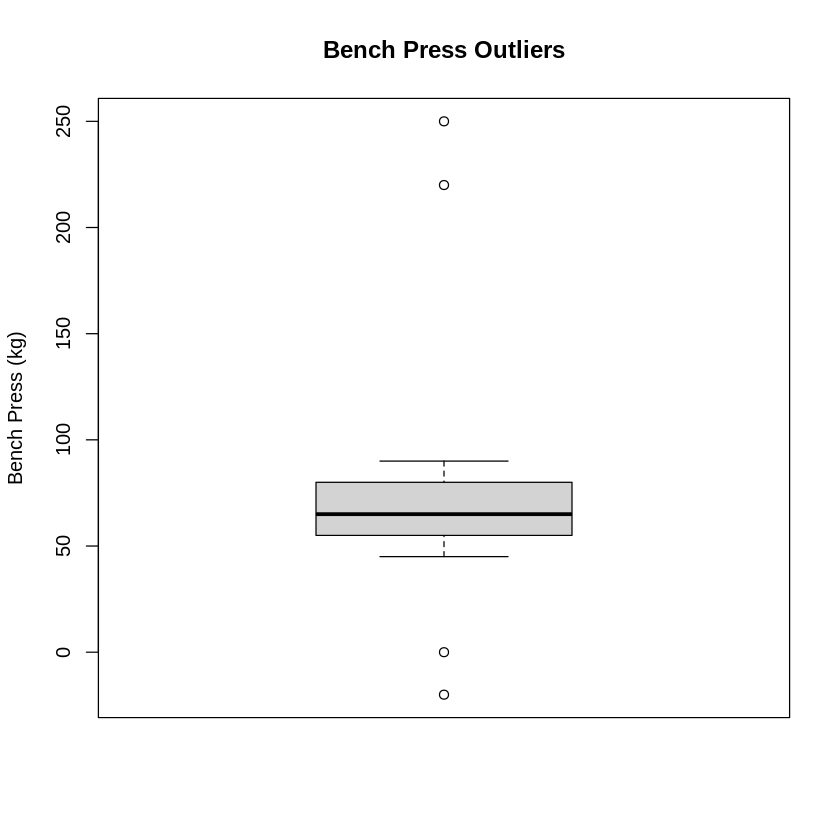

In [92]:
boxplot(data$Bench_Press_kg,
        main = "Bench Press Outliers",
        ylab = "Bench Press (kg)")

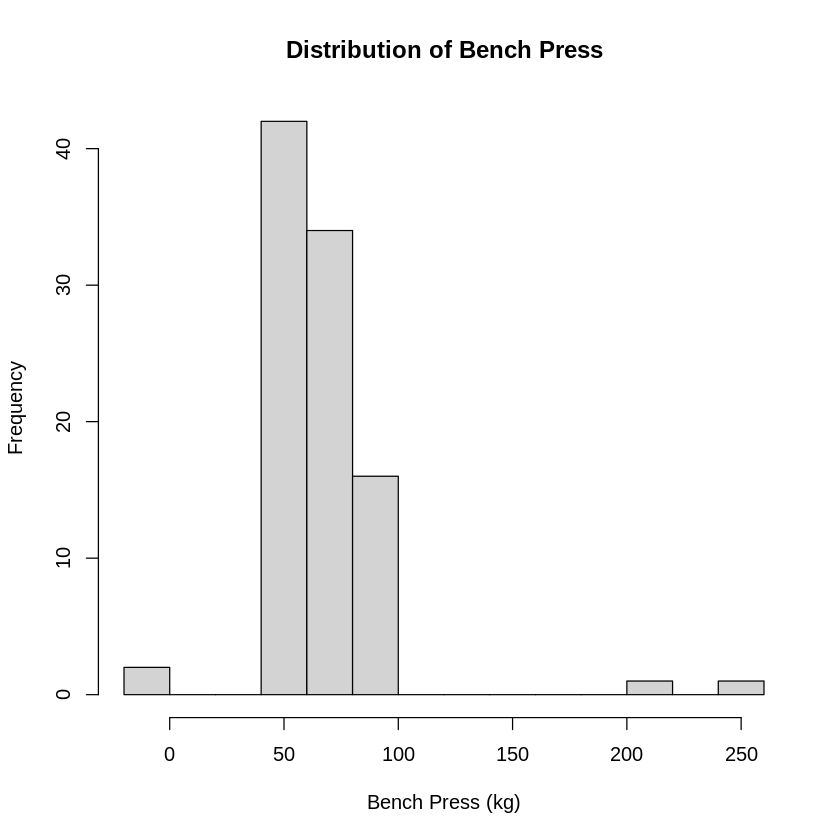

In [93]:
hist(data$Bench_Press_kg,
     main = "Distribution of Bench Press",
     xlab = "Bench Press (kg)",
     breaks = 10)

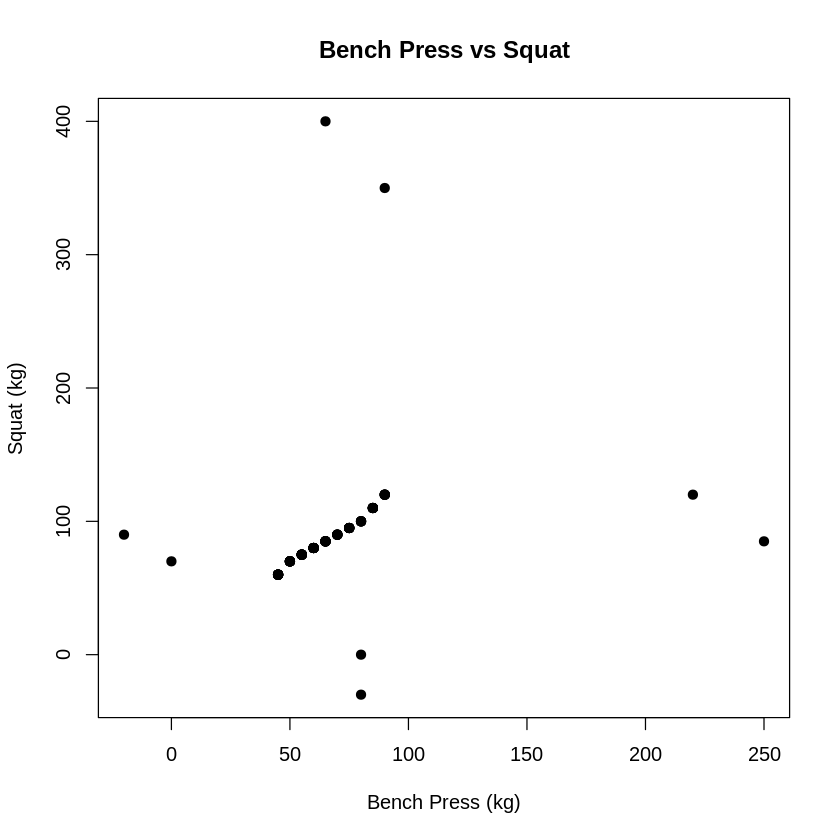

In [94]:
plot(data$Bench_Press_kg,
     data$Squat_kg,
     main = "Bench Press vs Squat",
     xlab = "Bench Press (kg)",
     ylab = "Squat (kg)",
     pch = 19)

**Objective 6: Examine the Distribution of Numerical Variables**

In [95]:
data$Bench_Normalized <- (data$Bench_Press_kg - min(data$Bench_Press_kg, na.rm = TRUE)) /
                         (max(data$Bench_Press_kg, na.rm = TRUE) -
                          min(data$Bench_Press_kg, na.rm = TRUE))

head(data$Bench_Normalized)

[1] 0.2407407 0.2592593 0.2777778 0.2962963 0.3148148        NA

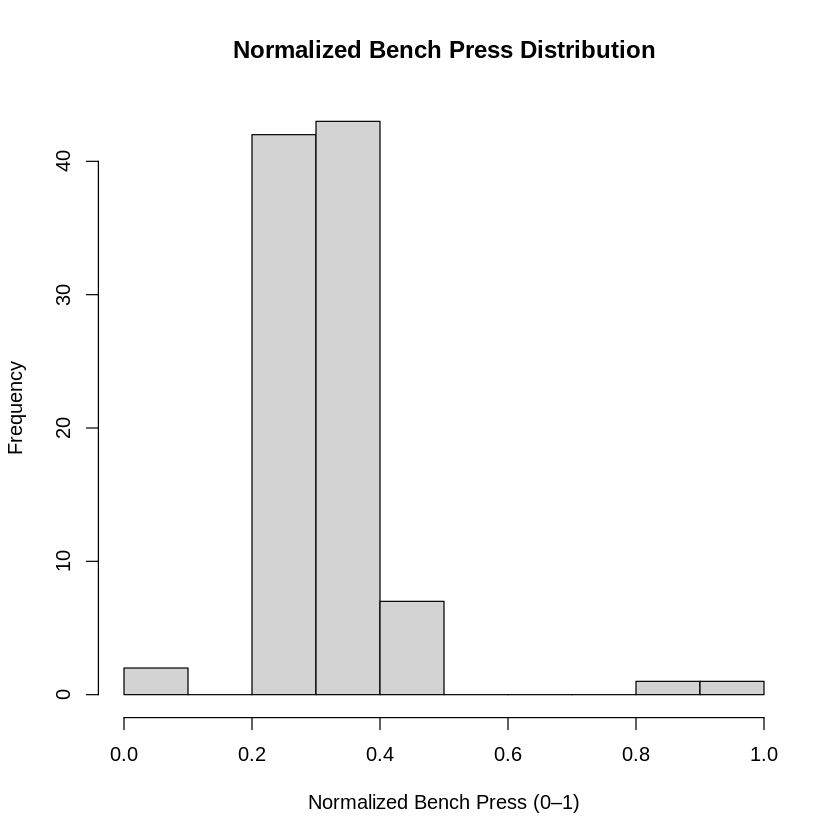

In [96]:
hist(data$Bench_Normalized,
     main = "Normalized Bench Press Distribution",
     xlab = "Normalized Bench Press (0–1)",
     ylab = "Frequency")

**Objective 7: Identify Inappropriate Data Types**

In [97]:
str(data)
cat("\n -----")
sapply(data, class)
cat("\n -----")
class(data$Calorie_Intake)

'data.frame':	100 obs. of  7 variables:
 $ Member_ID       : int  1 2 3 4 5 6 7 8 9 10 ...
 $ Name            : chr  "Rahul" "Arjun" "Karan" "Vikram" ...
 $ Bench_Press_kg  : num  45 50 55 60 65 NA 75 80 85 90 ...
 $ Lat_Pulldown_kg : num  50 55 60 65 70 75 80 85 90 NA ...
 $ Squat_kg        : num  60 70 75 80 85 90 95 100 110 120 ...
 $ Calorie_Intake  : chr  "1900.0" "2000.0" "2100.0" "2200.0" ...
 $ Bench_Normalized: num  0.241 0.259 0.278 0.296 0.315 ...

 -----

Member_ID             Name   Bench_Press_kg  Lat_Pulldown_kg 
       "integer"      "character"        "numeric"        "numeric" 
        Squat_kg   Calorie_Intake Bench_Normalized 
       "numeric"      "character"        "numeric"


 -----

[1] "character"

**Objective 8: Use summary() and Other R Functions**

In [98]:
summary(data)

   Member_ID            Name     Bench_Press_kg   Lat_Pulldown_kg 
 Min.   : 1.00   Length   :100   Min.   :-20.00   Min.   :-15.00  
 1st Qu.:20.75   N.unique : 65   1st Qu.: 55.00   1st Qu.: 60.00  
 Median :45.50   N.blank  :  0   Median : 65.00   Median : 70.00  
 Mean   :45.75   Min.nchar:  3   Mean   : 67.81   Mean   : 74.11  
 3rd Qu.:70.25   Max.nchar:  9   3rd Qu.: 80.00   3rd Qu.: 85.00  
 Max.   :95.00                   Max.   :250.00   Max.   :300.00  
                                 NAs    :4        NAs    :4       
    Squat_kg        Calorie_Intake Bench_Normalized
 Min.   :-30.00   Length   :100    Min.   :0.0000  
 1st Qu.: 73.75   N.unique : 15    1st Qu.:0.2778  
 Median : 85.00   N.blank  :  3    Median :0.3148  
 Mean   : 89.90   Min.nchar:  0    Mean   :0.3252  
 3rd Qu.: 96.25   Max.nchar: 13    3rd Qu.:0.3704  
 Max.   :400.00                    Max.   :1.0000  
 NAs    :4                         NAs    :4       

In [99]:
min(data$Bench_Press_kg, na.rm = TRUE)
max(data$Bench_Press_kg, na.rm = TRUE)

min(data$Lat_Pulldown_kg, na.rm = TRUE)
max(data$Lat_Pulldown_kg, na.rm = TRUE)

min(data$Squat_kg, na.rm = TRUE)
max(data$Squat_kg, na.rm = TRUE)

[1] -20

[1] 250

[1] -15

[1] 300

[1] -30

[1] 400

**Objective 9: Use Graphs to Visually Identify Data Problems**

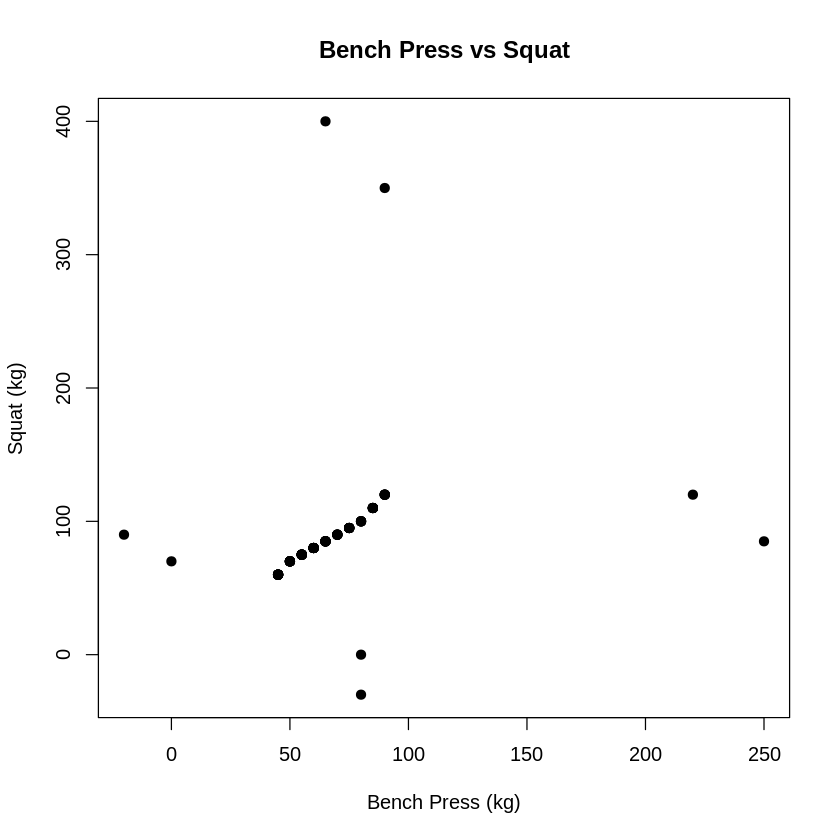

In [100]:
plot(data$Bench_Press_kg,
     data$Squat_kg,
     main = "Bench Press vs Squat",
     xlab = "Bench Press (kg)",
     ylab = "Squat (kg)",
     pch = 19)

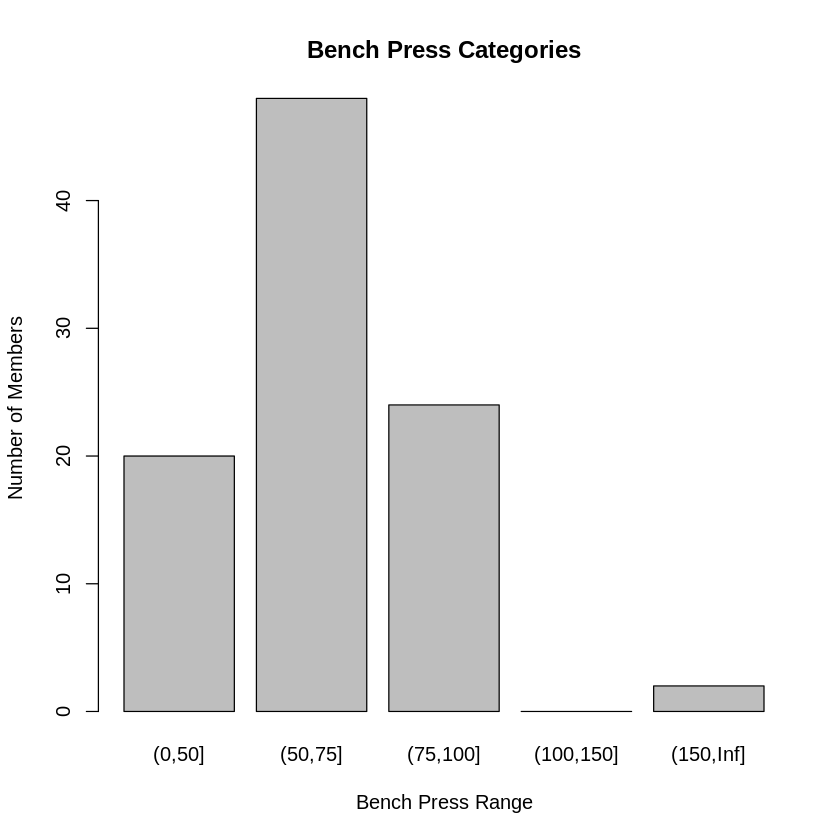

In [101]:
bench_groups <- cut(data$Bench_Press_kg,
                    breaks = c(0, 50, 75, 100, 150, Inf))

barplot(table(bench_groups),
        main = "Bench Press Categories",
        xlab = "Bench Press Range",
        ylab = "Number of Members")

**Objective 10: Prepare a Data-Quality Assessment Report**

In [102]:
quality_summary <- data.frame(
  Total_Rows = nrow(data),
  Total_Columns = ncol(data),
  Missing_Values = sum(is.na(data)),
  Duplicate_Rows = sum(duplicated(data))
)

quality_summary
cat("------\n")
sum(duplicated(data))

Total_Rows,Total_Columns,Missing_Values,Duplicate_Rows
<int>,<int>,<int>,<int>
100,7,16,5


------


[1] 5